# Process 1 — event log split into material flow + machine activities, and the energy curves of one activity

Rebuilds the two blocks of the paper figure, straight from the simulated process-1 event log
and one pipeline run:

1. **Material-flow layer** — the station-to-station route of a batch (`Water_supply → Destillation →
   Bottling → autoclaving_{1,2,3} → Individual_packaging → Warehousing`), autoclaving split into its
   parallel machines.
2. **Machine-activity layer** — the internal activities of ONE machine (`FOCUS_OBJECT`, default
   `autoclaving_3`): `prepare → heat → hold → cool`.
3. **Energy curves per machine activity** — every occurrence of that activity in the chosen case set,
   plotted against its own real elapsed time (no resampling, no barycenter).

The case set is the **test split of the pipeline run** (`RUN`), read from that run's own
`predicted_logs/<process>_test_set.parquet`, so the split is identical to the one the run evaluated on.

**Real vs simulated curves** — only `CURVE_SOURCE` changes:

| `CURVE_SOURCE`   | curves                                                                 |
|------------------|------------------------------------------------------------------------|
| `real_expanded`  | real sensor readings from the gold `df_expanded` (what this run shows)  |
| `run_real`       | `real` series of the run's saved curve file — cross-check of the above  |
| `run_predicted`  | `predicted` series of one approach — the **simulated** test curves      |

`run_*` needs a run with saved curves (`save_predicted_curves: True` in `01_pipeline.py`). Check which
runs under `results/` have `complete_curve_eval_results/<process>/<mode>/predicted_curves*.parquet`
and point `RUN` / `SIM_MODE` / `SIM_APPROACH` at one of them (section 8 below lists what the current
run has to offer).

Sections 1–7 build the single figure for the **real** version. Section 9 rebuilds the exact same
figure for the **simulated** version (predicted curves) using the config set in section 8 — it
doesn't just change the variables, it re-derives everything downstream of them (`run_dir`, the test
split, both nets, the curves, the panels) so the simulated process model and profiles actually
render instead of silently reusing the real run's data. The notebook produces exactly **two images**:
the real paper figure and the simulated one.


In [1]:
# ── Config ───────────────────────────────────────────────────────────────────
RUN             = 'experiment_976'   # dir under ../results: full name or any substring (latest match)
DATA_EXPERIMENT = '1'                # gold data experiment that run was fed with
PROCESS         = 'process_1'
SPLIT           = 'test'             # 'test' | 'train' | 'all'  — which cases the curves come from
FOCUS_OBJECT    = 'autoclaving_2'    # the machine the machine-activity layer zooms into

# Curve panels given as (phase, sensor).  The activity name is built as
# f'{FOCUS_OBJECT}_{phase}', so only the PHASE is spelled here.  Writing the whole activity by
# hand is how you end up asking for 'autoclaving_1' instead of 'autoclaving_1_heat' -- that
# matches no activity, yields 0 curves, and the panel is silently dropped.
# Set PANEL_PHASES = None to auto-pick the dominant sensor of every FOCUS_OBJECT activity.
PANEL_PHASES = [
    ('heat', 'autoclave_steam_demand_kW_energy_to_model'),
    ('hold', 'autoclave_steam_demand_kW_energy_to_model'),
    ('cool', 'autoclave_cooling_water_demand_kW_energy_to_model'),
]
PANELS = None if PANEL_PHASES is None else [(f'{FOCUS_OBJECT}_{ph}', s) for ph, s in PANEL_PHASES]

# ── Where the curves come from ───────────────────────────────────────────────
CURVE_SOURCE = 'real_expanded'   # 'real_expanded' | 'run_real' | 'run_predicted'

# Only used by 'run_real' / 'run_predicted':
SIM_SCOPE    = 'complete'        # 'complete' → complete_curve_eval_results/<process>/<SIM_MODE>/
                                 # 'schedule' → schedule_profile_eval_results/<process>/
SIM_MODE     = 'petri_net_budget_ml_plus_per_act'      # net + duration-model directory
                                 # best mode for process_1 by the run's own test_overall_error
                                 # (0.1136 vs 0.1182 for petri_net_heuristic_ml_plus_per_act)
SIM_APPROACH = 'ml_external'     # curve approach; '' → predicted_curves.parquet
SIM_SERIES   = None              # None → 'real' for run_real, 'predicted' for run_predicted.
                                 # 'schedule' scope also has: schedule, stochastic, bootstrap,
                                 # best, best_duration_corrected, best_budget
SIM_LOG      = 'auto'            # which log gives the activity windows:
                                 # 'auto' → real test log for real/schedule/stochastic/bootstrap,
                                 #          predicted_logs/<process>_<SIM_MODE>.parquet otherwise
                                 # 'real' | 'sim' to force it

# ── Plotting ─────────────────────────────────────────────────────────────────
MAX_CURVES   = 60                # occurrences drawn per panel (None = all)
NET_DPI      = 200               # graphviz render resolution for the two nets
NET_MARGIN   = 0.1               # graphviz page margin, inches (used to place the arrows)
OUT_DIR      = 'visuals/process_and_profiles'
SAVE         = True    # save the FINAL combined figure
SAVE_NETS    = False   # write the raw graphviz nets as separate PDFs
SHOW_INTERMEDIATE = False   # draw the net previews + the two standalone figures


In [2]:
import re
import tempfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
from IPython.display import Image, display

import pm4py
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.visualization.heuristics_net import visualizer as hn_vis

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 130,
})

REPO    = next(d for d in [Path.cwd(), *Path.cwd().parents]
               if (d / 'results').is_dir() and (d / 'data').is_dir())   # repo root, from anywhere
RESULTS = REPO / 'results'
GOLD    = REPO / 'data' / 'gold' / f'experiment_{DATA_EXPERIMENT}' / PROCESS / 'datasets'
OUT     = Path(OUT_DIR)
if SAVE:
    OUT.mkdir(parents=True, exist_ok=True)

_matches = [d for d in sorted(RESULTS.iterdir()) if d.is_dir() and (d.name == RUN or RUN in d.name)]
assert _matches, f'no run under {RESULTS} matching {RUN!r}'
run_dir = _matches[-1]

df_event_log = pd.read_parquet(GOLD / 'df_event_log.parquet')
df_expanded  = pd.read_parquet(GOLD / 'df_expanded.parquet')

SENSOR_COLS = [c for c in df_expanded.columns if c.endswith('_energy_to_model')]

print(f'run   : {run_dir.name}' + ('' if RUN == run_dir.name else f'   (latest match for {RUN!r})'))
print(f'gold  : {GOLD.relative_to(REPO)}')
print(f'log   : {len(df_event_log)} events, {df_event_log["case_id"].nunique()} cases, '
      f'{df_event_log["activity"].nunique()} activities')
print(f'energy: {len(df_expanded)} rows, {len(SENSOR_COLS)} sensors')


run   : experiment_976_20260726_103126   (latest match for 'experiment_976')
gold  : data/gold/experiment_1/process_1/datasets
log   : 41275 events, 2190 cases, 25 activities
energy: 271056 rows, 7 sensors


## 1. Case set — the run's own test split

Taken from `predicted_logs/<process>_test_set.parquet` when the run wrote one (exact same split the run
evaluated on); otherwise re-derived as the temporal split at the ratio printed in that run's
`pipeline_execution.log`.


In [3]:
_all_cases  = set(df_event_log['case_id'].dropna().unique())
_test_path  = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'

if _test_path.exists():
    test_cases  = set(pd.read_parquet(_test_path)['case_id'].dropna().unique())
    split_source = f'predicted_logs/{PROCESS}_test_set.parquet'
else:
    _log = (run_dir / 'pipeline_execution.log')
    _m = re.search(r'SPLIT \((\d+)% train', _log.read_text()) if _log.exists() else None
    _ratio = int(_m.group(1)) / 100 if _m else 0.80
    _case_start = df_event_log.groupby('case_id')['timestamp_start'].min().sort_values()
    _n_train = max(1, int(len(_case_start) * _ratio))
    test_cases = set(_case_start.index[_n_train:])
    split_source = f'temporal split re-derived at train_ratio={_ratio:.2f} (run saved no test set)'

train_cases = _all_cases - test_cases
cases = {'test': test_cases, 'train': train_cases, 'all': _all_cases}[SPLIT]

print(f'split source : {split_source}')
print(f'train / test : {len(train_cases)} / {len(test_cases)} cases')
print(f'SPLIT={SPLIT!r} → {len(cases)} cases used below')


split source : predicted_logs/process_1_test_set.parquet
train / test : 2100 / 90 cases
SPLIT='test' → 90 cases used below


## 2. Split the event log into the two layers

* **material flow** — one node per station, but the station `FOCUS_OBJECT` belongs to (`Autoclaving`) is
  broken up into its machines, so the parallel branches show up. Consecutive repeats of the same node are
  collapsed, so the edges are the station-to-station handovers of a batch.
* **machine activities** — every event of `FOCUS_OBJECT` only, at activity level.


In [4]:
el = (df_event_log[df_event_log['case_id'].isin(cases)]
      .sort_values(['case_id', 'timestamp_start'])
      .copy())

_focus_rows = el[el['object'] == FOCUS_OBJECT]
assert len(_focus_rows), f'{FOCUS_OBJECT!r} does not appear in this case set'
MACHINE_STATION = _focus_rows['station'].iloc[0]

# ── material-flow layer ──────────────────────────────────────────────────────
df_material = el.copy()
df_material['flow_node'] = np.where(df_material['station'] == MACHINE_STATION,
                                    df_material['object'], df_material['station'])
_prev = df_material.groupby('case_id')['flow_node'].shift(1)
df_material = df_material[df_material['flow_node'] != _prev].copy()

# ── machine-activity layer ───────────────────────────────────────────────────
df_machine = el[el['object'] == FOCUS_OBJECT].copy()

# activities of the focus machine, in process order (mean position within its own trace)
_order = (df_machine.assign(pos=df_machine.groupby('case_id').cumcount())
          .groupby('activity')['pos'].mean().sort_values())
MACHINE_ACTIVITIES = list(_order.index)

print(f'material flow  : {len(df_material)} handovers, nodes = '
      f'{list(df_material["flow_node"].value_counts().index)}')
print(f'machine layer  : {len(df_machine)} events on {FOCUS_OBJECT} '
      f'({df_machine["case_id"].nunique()} cases)')
print(f'  activities in process order: {MACHINE_ACTIVITIES}')
display(df_machine.groupby('activity').size().rename('events').to_frame().T)


material flow  : 612 handovers, nodes = ['Warehousing', 'Individual_packaging', 'Water_supply', 'Destillation', 'Bottling', 'autoclaving_2', 'autoclaving_3', 'autoclaving_1']
machine layer  : 164 events on autoclaving_2 (34 cases)
  activities in process order: ['autoclaving_2_prepare', 'autoclaving_2_heat', 'autoclaving_2_hold', 'autoclaving_2_cool']


activity,autoclaving_2_cool,autoclaving_2_heat,autoclaving_2_hold,autoclaving_2_prepare
events,42,42,42,38


## 3a. Material-flow net


In [5]:
def load_net_image(png):
    """Read a graphviz PNG and flatten it onto white -- its page margin is transparent,
    which otherwise shows up as a faint rectangle around the net."""
    im = mpimg.imread(png)
    if im.ndim == 3 and im.shape[2] == 4:
        rgb, alpha = im[..., :3], im[..., 3:4]
        im = rgb * alpha + (1.0 - alpha)
    return im


def _to_pm4py(df, activity_col):
    d = df.rename(columns={'case_id': 'case:concept:name',
                           activity_col: 'concept:name',
                           'timestamp_start': 'time:timestamp'})
    d = d[['case:concept:name', 'concept:name', 'time:timestamp']].copy()
    d['time:timestamp'] = pd.to_datetime(d['time:timestamp'])
    return pm4py.convert_to_event_log(d)


def heuristic_net(df, activity_col, pdf_name=None, **heu_kwargs):
    """Mine + render a heuristics net.  Returns (png_path, gviz) — the graphviz object is
    kept so cell 7b can read the node coordinates back out of it."""
    log = _to_pm4py(df, activity_col)
    net = heuristics_miner.apply_heu(log, parameters=heu_kwargs or None)
    gviz = hn_vis.apply(net)
    try:                                  # sharper rendering + a known margin
        gviz.graph_attr['dpi'] = str(NET_DPI)
        gviz.graph_attr['margin'] = str(NET_MARGIN)
    except Exception:
        pass
    png = tempfile.NamedTemporaryFile(suffix='.png', delete=False).name
    hn_vis.save(gviz, png)
    if SAVE_NETS and pdf_name:
        # hn_vis.save() writes PNG bytes whatever the extension -- render vector via graphviz
        gviz.render(str(OUT / Path(pdf_name).stem), format='pdf', cleanup=True)
        print(f'saved {OUT / pdf_name}')
    return png, gviz


png_material, gviz_material = heuristic_net(df_material, 'flow_node',
                                            f'net_material_flow_{PROCESS}_{SPLIT}.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_material))


## 3b. Machine-activity net (`FOCUS_OBJECT`)


In [6]:
png_machine, gviz_machine = heuristic_net(df_machine, 'activity',
                                          f'net_machine_{FOCUS_OBJECT}_{SPLIT}.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_machine))


## 4. Curve extraction

One curve per **occurrence** of an activity (not per case — a machine can run several cycles for the same
batch), taken from whichever source `CURVE_SOURCE` selects:

* `real_expanded` — rows of `df_expanded` labelled with that activity, grouped by
  `(case_id_log, timestamp_start_log)`, i.e. one group per event-log occurrence.
* `run_real` / `run_predicted` — the run's `predicted_curves*.parquet` (`case_id, sensor, series,
  t_minutes, value`, minutes since that curve's own case start), sliced by the activity windows of the
  matching log: the real test log for the real/schedule-driven series, the approach's own
  `predicted_logs/<process>_<SIM_MODE>.parquet` for the simulated series (its curves follow its own
  simulated schedule).


In [7]:
# Tolerance when slicing a run curve by an activity window, minutes.  Keep it at 0: back-to-back
# activities are only seconds apart, so any slack pulls the NEXT activity's first sample into the
# curve -- e.g. a hold curve flat at 22 kW ending on one 4007 kW sample of the following heat.
_EPS_MIN = 0.0
_curve_cache = {}


def curves_real_expanded(activity, sensor):
    """Returns a list of (t_minutes, value) pairs, t_minutes elapsed since the occurrence started."""
    sub = df_expanded[(df_expanded['activity_log'] == activity)
                      & (df_expanded['case_id_log'].isin(cases))].sort_values('datetime_energy')
    out = []
    for _, g in sub.groupby(['case_id_log', 'timestamp_start_log'], sort=True):
        v = g[sensor].to_numpy(dtype=float)
        t = (g['datetime_energy'] - g['datetime_energy'].iloc[0]).dt.total_seconds().to_numpy() / 60
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


def _run_curve_path():
    if SIM_SCOPE == 'complete':
        d = run_dir / 'complete_curve_eval_results' / PROCESS / SIM_MODE
    else:
        d = run_dir / 'schedule_profile_eval_results' / PROCESS
    if not d.exists():
        _runs_with_curves = sorted({p.relative_to(RESULTS).parts[0]
                                    for p in RESULTS.glob('*/**/predicted_curves*.parquet')})
        raise AssertionError(f'{d} does not exist — this run saved no curves for that scope/mode.\n'
                             f'Runs that did: {_runs_with_curves}')
    for name in ([f'predicted_curves_{SIM_APPROACH}.parquet'] if SIM_APPROACH else []) + ['predicted_curves.parquet']:
        if (d / name).exists():
            return d / name
    raise AssertionError(f'no predicted_curves file for SIM_APPROACH={SIM_APPROACH!r} in {d}.\n'
                         f'available: {sorted(p.name for p in d.glob("predicted_curves*.parquet"))}')


def _run_curves_df():
    if 'curves' not in _curve_cache:
        p = _run_curve_path()
        _curve_cache['curves'] = pd.read_parquet(p)
        print(f'curves from {p.relative_to(run_dir)}  '
              f'| series: {sorted(_curve_cache["curves"]["series"].unique())}')
    return _curve_cache['curves']


def _window_log(series):
    use_real = (SIM_LOG == 'real') or (SIM_LOG == 'auto' and
                                       series in ('real', 'schedule', 'stochastic', 'bootstrap'))
    p = (run_dir / 'predicted_logs' /
         (f'{PROCESS}_test_set.parquet' if use_real else f'{PROCESS}_{SIM_MODE}.parquet'))
    assert p.exists(), f'{p} missing — cannot place activity windows for series {series!r}'
    key = ('log', p.name)
    if key not in _curve_cache:
        log = pd.read_parquet(p)
        log['timestamp_start'] = pd.to_datetime(log['timestamp_start'])
        log['timestamp_end']   = pd.to_datetime(log['timestamp_end'])
        _curve_cache[key] = log
        print(f'windows from predicted_logs/{p.name}')
    return _curve_cache[key]


def curves_from_run(activity, sensor, series):
    """Returns a list of (t_minutes, value) pairs, t_minutes elapsed since the activity started."""
    dfc = _run_curves_df()
    assert series in set(dfc['series']), \
        f'series {series!r} not in file (have {sorted(dfc["series"].unique())})'
    dfc = dfc[(dfc['sensor'] == sensor) & (dfc['series'] == series)]
    if dfc.empty:
        return []
    by_case = {c: g.sort_values('t_minutes') for c, g in dfc.groupby('case_id')}

    log = _window_log(series)
    log = log[log['case_id'].isin(cases)]
    case_t0 = log.groupby('case_id')['timestamp_start'].min()

    out = []
    occ = log[log['activity'] == activity].sort_values(['case_id', 'timestamp_start'])
    for _, r in occ.iterrows():
        g = by_case.get(r['case_id'])
        if g is None:
            continue
        t0 = case_t0[r['case_id']]
        a = (r['timestamp_start'] - t0).total_seconds() / 60
        b = (r['timestamp_end']   - t0).total_seconds() / 60
        sel = g.loc[g['t_minutes'].between(a - _EPS_MIN, b + _EPS_MIN)]
        v = sel['value'].to_numpy(dtype=float)
        t = sel['t_minutes'].to_numpy(dtype=float) - a
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


def get_curves(activity, sensor):
    if CURVE_SOURCE == 'real_expanded':
        return curves_real_expanded(activity, sensor)
    series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    return curves_from_run(activity, sensor, series)


# label that ends up in titles and file names
if CURVE_SOURCE == 'real_expanded':
    SOURCE_TAG, SOURCE_LABEL = 'real', 'real (gold expanded)'
else:
    _series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    SOURCE_TAG   = f'{_series}_{SIM_MODE}' + (f'_{SIM_APPROACH}' if SIM_APPROACH else '')
    SOURCE_LABEL = f'{_series} — {SIM_MODE}' + (f' / {SIM_APPROACH}' if SIM_APPROACH else '')
print(f'CURVE_SOURCE={CURVE_SOURCE!r} → {SOURCE_LABEL}')


CURVE_SOURCE='real_expanded' → real (gold expanded)


## 5. Panels — which (activity, sensor) pairs to draw

With `PANELS = None` each activity of the focus machine gets the sensor whose peak is highest during that
activity, and activities whose curves are flat/zero are dropped.


In [8]:
def dominant_sensor(activity):
    sub = df_expanded[(df_expanded['activity_log'] == activity)
                      & (df_expanded['case_id_log'].isin(cases))]
    if sub.empty:
        return None
    peaks = {c: float(sub[c].max()) for c in SENSOR_COLS}
    best = max(peaks, key=peaks.get)
    return best if peaks[best] > 0 else None


if PANELS is None:
    panels = [(a, s) for a in MACHINE_ACTIVITIES if (s := dominant_sensor(a))]
else:
    panels = list(PANELS)

for a, s in panels:
    print(f'  {a:<28} {s}')

_bad = [a for a, _ in panels if a not in MACHINE_ACTIVITIES]
if _bad:
    print(f'!! these panels name activities {FOCUS_OBJECT} does not have: {_bad}'
          f'\n   available: {MACHINE_ACTIVITIES}')


  autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model


## 6. Curve data per panel

Extracted here, plotted only in the paper figure below (section 7) — no separate per-panel plot, no
barycenter/average, each occurrence keeps its own real elapsed time.


In [9]:
def draw_panel(ax, activity, sensor, curves, n_total, fs=1.0):
    """One profile panel.  The y axis is just 'kW' — the sensor is named in the title."""
    for t, v in curves:
        ax.plot(t, v, color='blue', alpha=0.15, lw=0.9)
    short = sensor.replace('_energy_to_model', '')
    ax.set_title(short, fontsize=13 * fs)
    ax.set_xlabel('Time since activity start (min)', fontsize=12 * fs)
    ax.set_ylabel('kW', fontsize=12 * fs)
    ax.tick_params(labelsize=10.5 * fs)
    ax.text(0.99, 0.02, f'n={len(curves)}' + ('' if len(curves) == n_total else f' of {n_total}'),
            transform=ax.transAxes, ha='right', va='bottom', fontsize=10 * fs, color='0.35')


panel_data = {}
for activity, sensor in panels:
    curves = get_curves(activity, sensor)
    if len(curves) < 2:
        print(f'!! {activity} / {sensor}: only {len(curves)} curve(s) — skipped')
        continue
    n_total = len(curves)
    used = curves[:MAX_CURVES] if MAX_CURVES else curves
    panel_data[(activity, sensor)] = dict(curves=used, n_total=n_total)
    print(f'{activity:<28} {sensor:<45} n={len(used)}' + ('' if len(used) == n_total else f' of {n_total}'))


autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model     n=42
autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model     n=42
autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model n=42


## 7. Paper figure — machine net **on** the material flow, arrows from the activities to their profiles

The only figure this notebook renders: the material flow fills the left block with the `FOCUS_OBJECT`
net sitting on its top-right corner (a leader line ties it back to that machine's own box in the
material flow), and each profile on the right is connected by a red arrow that stops right at the
profile's y-axis title, not crossing over any tick labels or plot text.

Arrow anchors come from graphviz itself — the mined net is asked for its `plain` layout, which gives the
box coordinates of every node, so an arrow starts at the real `autoclaving_3_heat` box edge and not at a
hard-coded pixel. Nodes that cannot be located fall back to the right edge of the machine-net box.
Curves are plotted on their own real elapsed time (minutes since the activity started) — no
resampling, no barycenter.


In [10]:
# ── Layout ───────────────────────────────────────────────────────────────────
PAPER_W, PAPER_H = 15.0, 9.0   # single-block figure size, inches
PROCESS_FRAC   = 0.66    # share of a block's width available to (material net + machine net)
NET_GAP        = 0.02    # gap between the two nets
PAPER_GAP      = 0.085   # gap process block -> profile block; must clear the y-axis label,
                         # which is drawn to the LEFT of the panel and sits inside this gap
PANEL_W_SCALE  = 1.00    # panels fill the width left over by the process block
PANEL_H_SCALE  = 0.88
MH_MAX         = 0.800   # net height cap (leaves room for titles + caption)
MX             = 0.012   # left margin of the process block, in block fractions
PAPER_BOXES    = True
ARROW_COLOR    = '#c00000'
BOX_COLORS     = ('#e8a33d', '#7fb3d5')   # process block, profile block
CAPTION_REAL   = '(a) real test set process and energy profiles'
CAPTION_SIM    = '(b) simulated process and energy profiles'

import shlex
from matplotlib.patches import ConnectionPatch, FancyBboxPatch


def net_node_positions(gviz, png):
    """activity -> (x, y, w, h) of its node box, as fractions of the rendered image.

    graphviz's 'plain' output gives the layout in inches without the page margins, so the
    padding is recovered from the PNG's own size -- no assumption about graphviz defaults."""
    try:
        txt = gviz.pipe(format='plain').decode('utf-8', 'replace')
    except Exception as exc:
        print(f'! graphviz layout unavailable ({exc}) — arrows anchor to the box edge')
        return {}
    rows = []
    W0 = H0 = None
    for line in txt.splitlines():
        try:
            parts = shlex.split(line)
        except ValueError:
            continue
        if not parts:
            continue
        if parts[0] == 'graph' and len(parts) >= 4:
            W0, H0 = float(parts[2]), float(parts[3])
        elif parts[0] == 'node' and len(parts) >= 7:
            rows.append([float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5]), parts[6]])
    if W0 is None:
        return {}
    _h_px, _w_px = mpimg.imread(png).shape[:2]
    dpi = float(gviz.graph_attr.get('dpi', 96) or 96)
    pad_x, pad_y = (_w_px / dpi - W0) / 2, (_h_px / dpi - H0) / 2      # margins, inches
    W, H = W0 + 2 * pad_x, H0 + 2 * pad_y
    # graphviz 'plain' reports the node CENTRE (x, y) and its full width/height -- convert to the
    # top-left corner, otherwise every anchor sits half a box off and the arrows miss the node.
    return {label.split(' (')[0].strip():
            ((x - w / 2 + pad_x) / W, 1 - (y + h / 2 + pad_y) / H, w / W, h / H)
            for x, y, w, h, label in rows}


def make_block(png_material, gviz_material, png_machine, gviz_machine, panel_data, focus):
    """Bundle everything one figure-block needs, so a block survives being recomputed later."""
    return dict(png_material=png_material, gviz_material=gviz_material,
                png_machine=png_machine, gviz_machine=gviz_machine,
                panel_data=dict(panel_data), focus=focus)


def _net_inches(png):
    """The net's true size in graphviz inches (it was rendered at NET_DPI)."""
    h_px, w_px = mpimg.imread(png).shape[:2]
    return w_px / NET_DPI, h_px / NET_DPI


def plan_blocks(blocks, fig_w, fig_h, rw=1.0, rh=1.0):
    """One shared scale + profile x-origin for a set of blocks.

    Each block's nets are mined separately, so the real and simulated material nets come out with
    different aspect ratios and pixel sizes.  Letting every block size itself from its own net is
    what made one half of the comparison look bigger than the other.  Instead pick a single scale
    (figure-inches per graphviz-inch) that every block can live with -- so a node box is the same
    physical size everywhere -- plus one common profile x-origin so the panels line up too."""
    W, H = fig_w * rw, fig_h * rh
    dims = [(_net_inches(b['png_material']), _net_inches(b['png_machine'])) for b in blocks]
    scale = min(min(MH_MAX * H / max(m[1], c[1]),
                    (PROCESS_FRAC - NET_GAP) * W / (m[0] + c[0]))
                for m, c in dims)
    proc_w = max(scale * (m[0] + c[0]) / W + NET_GAP for m, c in dims)
    return dict(scale=scale, proc_w=proc_w, px=MX + proc_w + PAPER_GAP)


def draw_block(fig, region, blk, caption, fig_w, fig_h, plan, fs=1.0):
    """Draw one process+profiles block into `region` = (x0, y0, w, h) of `fig`.

    Everything is computed in block-relative coordinates and mapped into the region, so the same
    code renders a standalone figure (region = the whole figure) and one half of the side-by-side
    comparison.  `plan` carries the shared scale, which is what keeps the two halves comparable."""
    rx0, ry0, rw, rh = region
    W, H = fig_w * rw, fig_h * rh                      # effective inches of this block
    RA = lambda x, y, w, h: [rx0 + x * rw, ry0 + y * rh, w * rw, h * rh]
    RP = lambda x, y: (rx0 + x * rw, ry0 + y * rh)

    mat = load_net_image(blk['png_material'])
    mac = load_net_image(blk['png_machine'])
    mat_xy  = net_node_positions(blk['gviz_material'], blk['png_material'])
    node_xy = net_node_positions(blk['gviz_machine'],  blk['png_machine'])

    # both nets at the shared scale -> identical node sizes across blocks
    s = plan['scale']
    mw_in, mh_in = _net_inches(blk['png_material'])
    cw_in, ch_in = _net_inches(blk['png_machine'])
    mw, mh = s * mw_in / W, s * mh_in / H
    iw, ih = s * cw_in / W, s * ch_in / H

    my = 0.108        # leaves the caption clear of the frame bottom
    # centre this block's nets inside the COMMON process width.  The blocks' nets are mined
    # separately and come out different widths, so left-aligning them against a shared profile
    # x-origin leaves a lopsided gap in whichever block is narrower.
    mx = MX + (plan['proc_w'] - (mw + NET_GAP + iw)) / 2
    top = my + max(mh, ih)                             # both nets share a top edge

    ax_mat = fig.add_axes(RA(mx, top - mh, mw, mh))
    ax_mat.imshow(mat)
    ax_mat.set_title('Material flow activities', fontsize=15 * fs)
    ax_mat.axis('off')

    ix = mx + mw + NET_GAP
    ax_mac = fig.add_axes(RA(ix, top - ih, iw, ih), zorder=5)
    ax_mac.imshow(mac)
    ax_mac.set_title(f"Machine activities — {blk['focus']}", fontsize=14 * fs, pad=4)
    ax_mac.set_xticks([]); ax_mac.set_yticks([])
    ax_mac.set_facecolor('white')
    for sp in ax_mac.spines.values():       # rcParams hide top/right — force all four
        sp.set_visible(True); sp.set_edgecolor('0.5'); sp.set_linewidth(1.1 * fs)

    # leader line: the machine's own box in the material flow → the net that zooms into it
    if blk['focus'] in mat_xy:
        fx, fy, fw_, _fh = mat_xy[blk['focus']]
        hpx, wpx = mat.shape[0], mat.shape[1]
        fig.add_artist(ConnectionPatch(
            xyA=((fx + fw_ / 2) * wpx, fy * hpx), coordsA=ax_mat.transData,   # node top edge
            xyB=(0.0, 0.5), coordsB=ax_mac.transAxes,                         # net left edge, mid height
            arrowstyle='-|>', mutation_scale=16 * fs, linewidth=1.5 * fs,
            color=ARROW_COLOR, connectionstyle='arc3,rad=0.0',
            shrinkA=0, shrinkB=0, zorder=6))
    else:
        print(f"! {blk['focus']!r} not located in material net — no leader line drawn")

    # ── profiles ─────────────────────────────────────────────────────────────
    px = plan['px']
    pw = (0.972 - px) * PANEL_W_SCALE
    n = max(len(blk['panel_data']), 1)
    pad = 0.105          # room for each panel's title + the x-label of the one above
    ph = (max(mh, ih) * PANEL_H_SCALE - pad * (n - 1)) / n
    panel_axes = []
    for i, ((activity, sensor), d) in enumerate(blk['panel_data'].items()):
        ax = fig.add_axes(RA(px, top - (i + 1) * ph - i * pad, pw, ph))
        draw_panel(ax, activity, sensor, d['curves'], d['n_total'], fs=fs)
        panel_axes.append((activity, ax))

    # ── arrows: activity box → its profile, stopping at the y-axis title ─────
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    hpx, wpx = mac.shape[0], mac.shape[1]
    for activity, axp in panel_axes:
        if activity in node_xy:
            fx, fy, fw_, fh_ = node_xy[activity]
            xyA, cA = ((fx + fw_) * wpx, (fy + fh_ / 2) * hpx), ax_mac.transData
        else:
            xyA, cA = (1.0, 0.5), ax_mac.transAxes
        bb = axp.yaxis.label.get_window_extent(renderer=rend)
        xyB = fig.transFigure.inverted().transform((bb.x0, (bb.y0 + bb.y1) / 2))
        fig.add_artist(ConnectionPatch(
            xyA=xyA, coordsA=cA, xyB=xyB, coordsB=fig.transFigure,
            arrowstyle='-|>', mutation_scale=22 * fs, linewidth=2.0 * fs,
            color=ARROW_COLOR, connectionstyle='arc3,rad=0.0',
            shrinkA=0, shrinkB=4, zorder=30))

    # ── frames + caption ─────────────────────────────────────────────────────
    if PAPER_BOXES:
        bh = max(mh, ih)
        fb = my - 0.055                     # frame bottom; the gap below holds its label
        proc = (MX - 0.012, fb, plan['proc_w'] + 0.026, bh + 0.099)
        prof = (px - 0.048, fb, pw + 0.066, bh + 0.099)
        for (bx, by, bw, bhh), ec in zip((proc, prof), BOX_COLORS):
            fig.patches.append(FancyBboxPatch(
                (rx0 + bx * rw, ry0 + by * rh), bw * rw, bhh * rh,
                boxstyle='round,pad=0.004,rounding_size=0.015',
                transform=fig.transFigure, facecolor='none', edgecolor=ec,
                linewidth=1.8 * fs, zorder=0))
        for cx, lbl in ((MX + plan['proc_w'] / 2, 'Process'), (px + pw / 2, 'Energy')):
            fig.text(*RP(cx, fb + 0.016), lbl, ha='center', va='bottom',
                     fontsize=15 * fs, color='0.25')
    if caption:
        fig.text(*RP(0.5, 0.012), caption, ha='center', va='bottom', fontsize=17 * fs)


# ── the real block, and its standalone figure ────────────────────────────────
BLOCK_REAL = make_block(png_material, gviz_material, png_machine, gviz_machine,
                        panel_data, FOCUS_OBJECT)

print('real block ready — it is rendered only in the final combined figure')

if SHOW_INTERMEDIATE:
    fig = plt.figure(figsize=(PAPER_W, PAPER_H))
    draw_block(fig, (0.0, 0.0, 1.0, 1.0), BLOCK_REAL, CAPTION_REAL, PAPER_W, PAPER_H,
               plan_blocks([BLOCK_REAL], PAPER_W, PAPER_H))
    plt.show()


real block ready — it is rendered only in the final combined figure


In [11]:
## 8. Next: the simulated curves of the best approach

# Set in cell 1 and re-run everything below it:

# ```python
RUN          = 'experiment_976'                        # a run with save_predicted_curves: True
CURVE_SOURCE = 'run_predicted'
SIM_SCOPE    = 'complete'                              # complete_curve_eval_results/<process>/<mode>/
SIM_MODE     = 'petri_net_budget_ml_plus_per_act'      # the best net + duration model
#                                                      (lowest test_overall_error for process_1)
SIM_APPROACH = 'ml_external'                           # the best curve approach
# ```

# `CURVE_SOURCE = 'run_real'` with the same `RUN` gives the real curves out of the same file — a like-for-like
# reference for the simulated panels (it slices the real test log instead of the simulated one).
# Available modes / approaches for a run:

# ```python
sorted(p.name for p in (run_dir / 'complete_curve_eval_results' / PROCESS).iterdir())
sorted(p.name for p in (run_dir / 'complete_curve_eval_results' / PROCESS / SIM_MODE).glob('predicted_curves*.parquet'))
# ```


['predicted_curves.parquet',
 'predicted_curves_exemplar.parquet',
 'predicted_curves_median_activity_sensor.parquet',
 'predicted_curves_ml_external.parquet',
 'predicted_curves_ml_external_calib.parquet',
 'predicted_curves_ml_external_wcounts.parquet',
 'predicted_curves_ml_external_wmetric.parquet',
 'predicted_curves_ml_rawspace.parquet']

In [12]:
# What this run has to offer (empty output = the run saved no curves)
for scope, base in (('complete', run_dir / 'complete_curve_eval_results' / PROCESS),
                    ('schedule', run_dir / 'schedule_profile_eval_results' / PROCESS)):
    if not base.exists():
        print(f'{scope}: —')
        continue
    files = sorted(base.glob('**/predicted_curves*.parquet'))
    print(f'{scope}: {len(files)} curve file(s)')
    for p in files[:20]:
        print(f'   {p.relative_to(base)}')


complete: 72 curve file(s)
   petri_net_alpha/predicted_curves.parquet
   petri_net_alpha/predicted_curves_exemplar.parquet
   petri_net_alpha/predicted_curves_median_activity_sensor.parquet
   petri_net_alpha/predicted_curves_ml_external.parquet
   petri_net_alpha/predicted_curves_ml_external_calib.parquet
   petri_net_alpha/predicted_curves_ml_external_wcounts.parquet
   petri_net_alpha/predicted_curves_ml_external_wmetric.parquet
   petri_net_alpha/predicted_curves_ml_rawspace.parquet
   petri_net_alpha_ml_plus_global/predicted_curves.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_exemplar.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_median_activity_sensor.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_ml_external.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_ml_external_calib.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_ml_external_wcounts.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_ml_external_wmetric.

## 9. Simulated version — the simulation's OWN process model and its own curves

The second and last figure. Everything in it comes from the simulation — **the gold event log is not
read at all** below this point:

* both nets are mined from `predicted_logs/<process>_<SIM_MODE>.parquet` (the simulated log),
* the curves are the `predicted` series of the same run.

That matters: earlier this section mined the nets from the gold log while plotting simulated curves,
so a box could read `autoclaving_3_heat (35)` next to a panel showing `n=7`. Those were two different
files. Now the node counts and the curve counts are the same number, and the figure shows how many
instances the simulation *actually* produced for this machine.

Because of that, the simulated figure will not match the real one instance-for-instance — the
simulation does not reproduce the real split of batches across the parallel machines (see the
comparison table printed in 9.6). That is a property of the model, and it is now visible in the
figure instead of hidden behind a real-data process model.


In [13]:
# ── 9.1 re-resolve run_dir for the new RUN, reset the curve cache ────────────
_matches = [d for d in sorted(RESULTS.iterdir()) if d.is_dir() and (d.name == RUN or RUN in d.name)]
assert _matches, f'no run under {RESULTS} matching {RUN!r}'
run_dir = _matches[-1]
_curve_cache.clear()   # keyed off the previous run_dir — stale otherwise

print(f'run   : {run_dir.name}' + ('' if RUN == run_dir.name else f'   (latest match for {RUN!r})'))
print(f'source: CURVE_SOURCE={CURVE_SOURCE!r}, SIM_MODE={SIM_MODE!r}, SIM_APPROACH={SIM_APPROACH!r}')


run   : experiment_976_20260726_103126   (latest match for 'experiment_976')
source: CURVE_SOURCE='run_predicted', SIM_MODE='petri_net_budget_ml_plus_per_act', SIM_APPROACH='ml_external'


In [14]:
# ── 9.2 test split for this run (same logic as cell 1) ───────────────────────
_all_cases  = set(df_event_log['case_id'].dropna().unique())
_test_path  = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'

if _test_path.exists():
    test_cases  = set(pd.read_parquet(_test_path)['case_id'].dropna().unique())
    split_source = f'predicted_logs/{PROCESS}_test_set.parquet'
else:
    _log = (run_dir / 'pipeline_execution.log')
    _m = re.search(r'SPLIT \((\d+)% train', _log.read_text()) if _log.exists() else None
    _ratio = int(_m.group(1)) / 100 if _m else 0.80
    _case_start = df_event_log.groupby('case_id')['timestamp_start'].min().sort_values()
    _n_train = max(1, int(len(_case_start) * _ratio))
    test_cases = set(_case_start.index[_n_train:])
    split_source = f'temporal split re-derived at train_ratio={_ratio:.2f} (run saved no test set)'

train_cases = _all_cases - test_cases
cases = {'test': test_cases, 'train': train_cases, 'all': _all_cases}[SPLIT]

print(f'split source : {split_source}')
print(f'train / test : {len(train_cases)} / {len(test_cases)} cases')
print(f'SPLIT={SPLIT!r} → {len(cases)} cases used below')


split source : predicted_logs/process_1_test_set.parquet
train / test : 2100 / 90 cases
SPLIT='test' → 90 cases used below


In [15]:
# ── 9.3 material-flow / machine-activity layers — FROM THE SIMULATED LOG ─────
# Nothing here reads the gold event log: the process model below is the simulation's own
# behaviour, so the node counts in the nets match the n= on the curves.
# The simulated log carries the machine in `resource_id` (e.g. 'autoclaving_3'); the station is
# that resource with any trailing machine index stripped ('autoclaving_3' -> 'Autoclaving'),
# a rule verified to reproduce the gold object/station mapping exactly.
_sim_series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
el = _window_log(_sim_series).copy()
el = el[el['case_id'].isin(cases)].sort_values(['case_id', 'timestamp_start']).copy()

el['object']  = el['resource_id']
el['station'] = el['object'].astype(str).str.replace(r'_\d+$', '', regex=True).str.capitalize()

_focus_rows = el[el['object'] == FOCUS_OBJECT]
assert len(_focus_rows), f'{FOCUS_OBJECT!r} never appears in the simulated log for this case set'
MACHINE_STATION = _focus_rows['station'].iloc[0]

# ── material-flow layer ──────────────────────────────────────────────────────
df_material = el.copy()
df_material['flow_node'] = np.where(df_material['station'] == MACHINE_STATION,
                                    df_material['object'], df_material['station'])
_prev = df_material.groupby('case_id')['flow_node'].shift(1)
df_material = df_material[df_material['flow_node'] != _prev].copy()

# ── machine-activity layer ───────────────────────────────────────────────────
df_machine = el[el['object'] == FOCUS_OBJECT].copy()

_order = (df_machine.assign(pos=df_machine.groupby('case_id').cumcount())
          .groupby('activity')['pos'].mean().sort_values())
MACHINE_ACTIVITIES = list(_order.index)

print('layers built from the SIMULATED log — the gold log is not used here')
print(f'material flow  : {len(df_material)} handovers, nodes = '
      f'{list(df_material["flow_node"].value_counts().index)}')
print(f'machine layer  : {len(df_machine)} events on {FOCUS_OBJECT} '
      f'({df_machine["case_id"].nunique()} simulated cases)')
print(f'  activities in process order: {MACHINE_ACTIVITIES}')
display(df_machine.groupby('activity').size().rename('events').to_frame().T)


windows from predicted_logs/process_1_petri_net_budget_ml_plus_per_act.parquet
layers built from the SIMULATED log — the gold log is not used here
material flow  : 649 handovers, nodes = ['Individual_packaging', 'Warehousing', 'Water_supply', 'Destillation', 'Bottling', 'autoclaving_2', 'autoclaving_1', 'autoclaving_3']
machine layer  : 193 events on autoclaving_2 (42 simulated cases)
  activities in process order: ['autoclaving_2_prepare', 'autoclaving_2_heat', 'autoclaving_2_hold', 'autoclaving_2_cool']


activity,autoclaving_2_cool,autoclaving_2_heat,autoclaving_2_hold,autoclaving_2_prepare
events,42,54,49,48


In [16]:
# ── 9.4 re-mine both nets for this run's layers ───────────────────────────────
png_material, gviz_material = heuristic_net(df_material, 'flow_node',
                                            f'net_material_flow_{PROCESS}_{SPLIT}_sim.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_material))

In [17]:
png_machine, gviz_machine = heuristic_net(df_machine, 'activity',
                                          f'net_machine_{FOCUS_OBJECT}_{SPLIT}_sim.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_machine))


In [18]:
# ── 9.5 source label + panels for this config ─────────────────────────────────
if CURVE_SOURCE == 'real_expanded':
    SOURCE_TAG, SOURCE_LABEL = 'real', 'real (gold expanded)'
else:
    _series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    SOURCE_TAG   = f'{_series}_{SIM_MODE}' + (f'_{SIM_APPROACH}' if SIM_APPROACH else '')
    SOURCE_LABEL = f'{_series} — {SIM_MODE}' + (f' / {SIM_APPROACH}' if SIM_APPROACH else '')
print(f'CURVE_SOURCE={CURVE_SOURCE!r} → {SOURCE_LABEL}')

if PANELS is None:
    panels = [(a, s) for a in MACHINE_ACTIVITIES if (s := dominant_sensor(a))]
else:
    panels = list(PANELS)

for a, s in panels:
    print(f'  {a:<28} {s}')

_bad = [a for a, _ in panels if a not in MACHINE_ACTIVITIES]
if _bad:
    print(f'!! these panels name activities {FOCUS_OBJECT} does not have: {_bad}'
          f'\n   available: {MACHINE_ACTIVITIES}')


CURVE_SOURCE='run_predicted' → predicted — petri_net_budget_ml_plus_per_act / ml_external
  autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model


In [19]:
# ── 9.6 curve data per panel, from the predicted series ──────────────────────
panel_data = {}
for activity, sensor in panels:
    curves = get_curves(activity, sensor)
    if len(curves) < 2:
        print(f'!! {activity} / {sensor}: only {len(curves)} curve(s) — skipped')
        continue
    n_total = len(curves)
    used = curves[:MAX_CURVES] if MAX_CURVES else curves
    panel_data[(activity, sensor)] = dict(curves=used, n_total=n_total)
    print(f'{activity:<28} {sensor:<45} n={len(used)}' + ('' if len(used) == n_total else f' of {n_total}'))

# ── why the simulated panels can hold fewer curves than the real ones ────────
# The curve file itself is complete (all test cases, both series).  What differs is the
# *simulated event log*: the model decides which of the parallel machines each batch goes to,
# and it does not reproduce the real load split across them.  So a machine the simulation
# under-uses simply has fewer occurrences to slice curves out of.
_real_log = pd.read_parquet(run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet')
_sim_log  = _window_log(SIM_SERIES or 'predicted')
_cmp = pd.DataFrame({
    'real': _real_log[_real_log['case_id'].isin(cases)]['activity'].value_counts(),
    'sim':  _sim_log[_sim_log['case_id'].isin(cases)]['activity'].value_counts(),
}).fillna(0).astype(int)
_cmp = _cmp[_cmp.index.str.startswith(MACHINE_STATION.lower())].sort_index()
if len(_cmp):
    print(f'\noccurrences per {MACHINE_STATION} activity — real test log vs simulated log:')
    print(_cmp.to_string())
    print('→ the machine split is a property of the simulation, not of the curve extraction.')


curves from complete_curve_eval_results/process_1/petri_net_budget_ml_plus_per_act/predicted_curves_ml_external.parquet  | series: ['predicted', 'real']
autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model     n=54
autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model     n=49
autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model n=42

occurrences per Autoclaving activity — real test log vs simulated log:
                       real  sim
activity                        
autoclaving_1_cool       24   27
autoclaving_1_heat       24   28
autoclaving_1_hold       24   28
autoclaving_1_prepare    22   28
autoclaving_2_cool       48   42
autoclaving_2_heat       48   54
autoclaving_2_hold       48   49
autoclaving_2_prepare    44   48
autoclaving_3_cool       31   21
autoclaving_3_heat       31   21
autoclaving_3_hold       31   21
autoclaving_3_prepare    30   21
→ the machine split is a property of the simulation, not of the curve

In [20]:
# ── 9.7 the simulated block, and its standalone figure ───────────────────────
BLOCK_SIM = make_block(png_material, gviz_material, png_machine, gviz_machine,
                       panel_data, FOCUS_OBJECT)

print('simulated block ready — it is rendered only in the final combined figure')

if SHOW_INTERMEDIATE:
    fig = plt.figure(figsize=(PAPER_W, PAPER_H))
    draw_block(fig, (0.0, 0.0, 1.0, 1.0), BLOCK_SIM, CAPTION_SIM, PAPER_W, PAPER_H,
               plan_blocks([BLOCK_SIM], PAPER_W, PAPER_H))
    plt.show()


simulated block ready — it is rendered only in the final combined figure


## 10. The paper figure — real (a) and simulated (b) side by side

Both blocks in one figure, drawn by the same `draw_block` used above: **(a)** the real test set on the
left, **(b)** the simulation on the right. Each block keeps its own mined nets and its own curves, so
the counts inside a block always agree with each other, and the two blocks can be compared directly.


saved visuals/process_and_profiles/paper_figure_combined.pdf


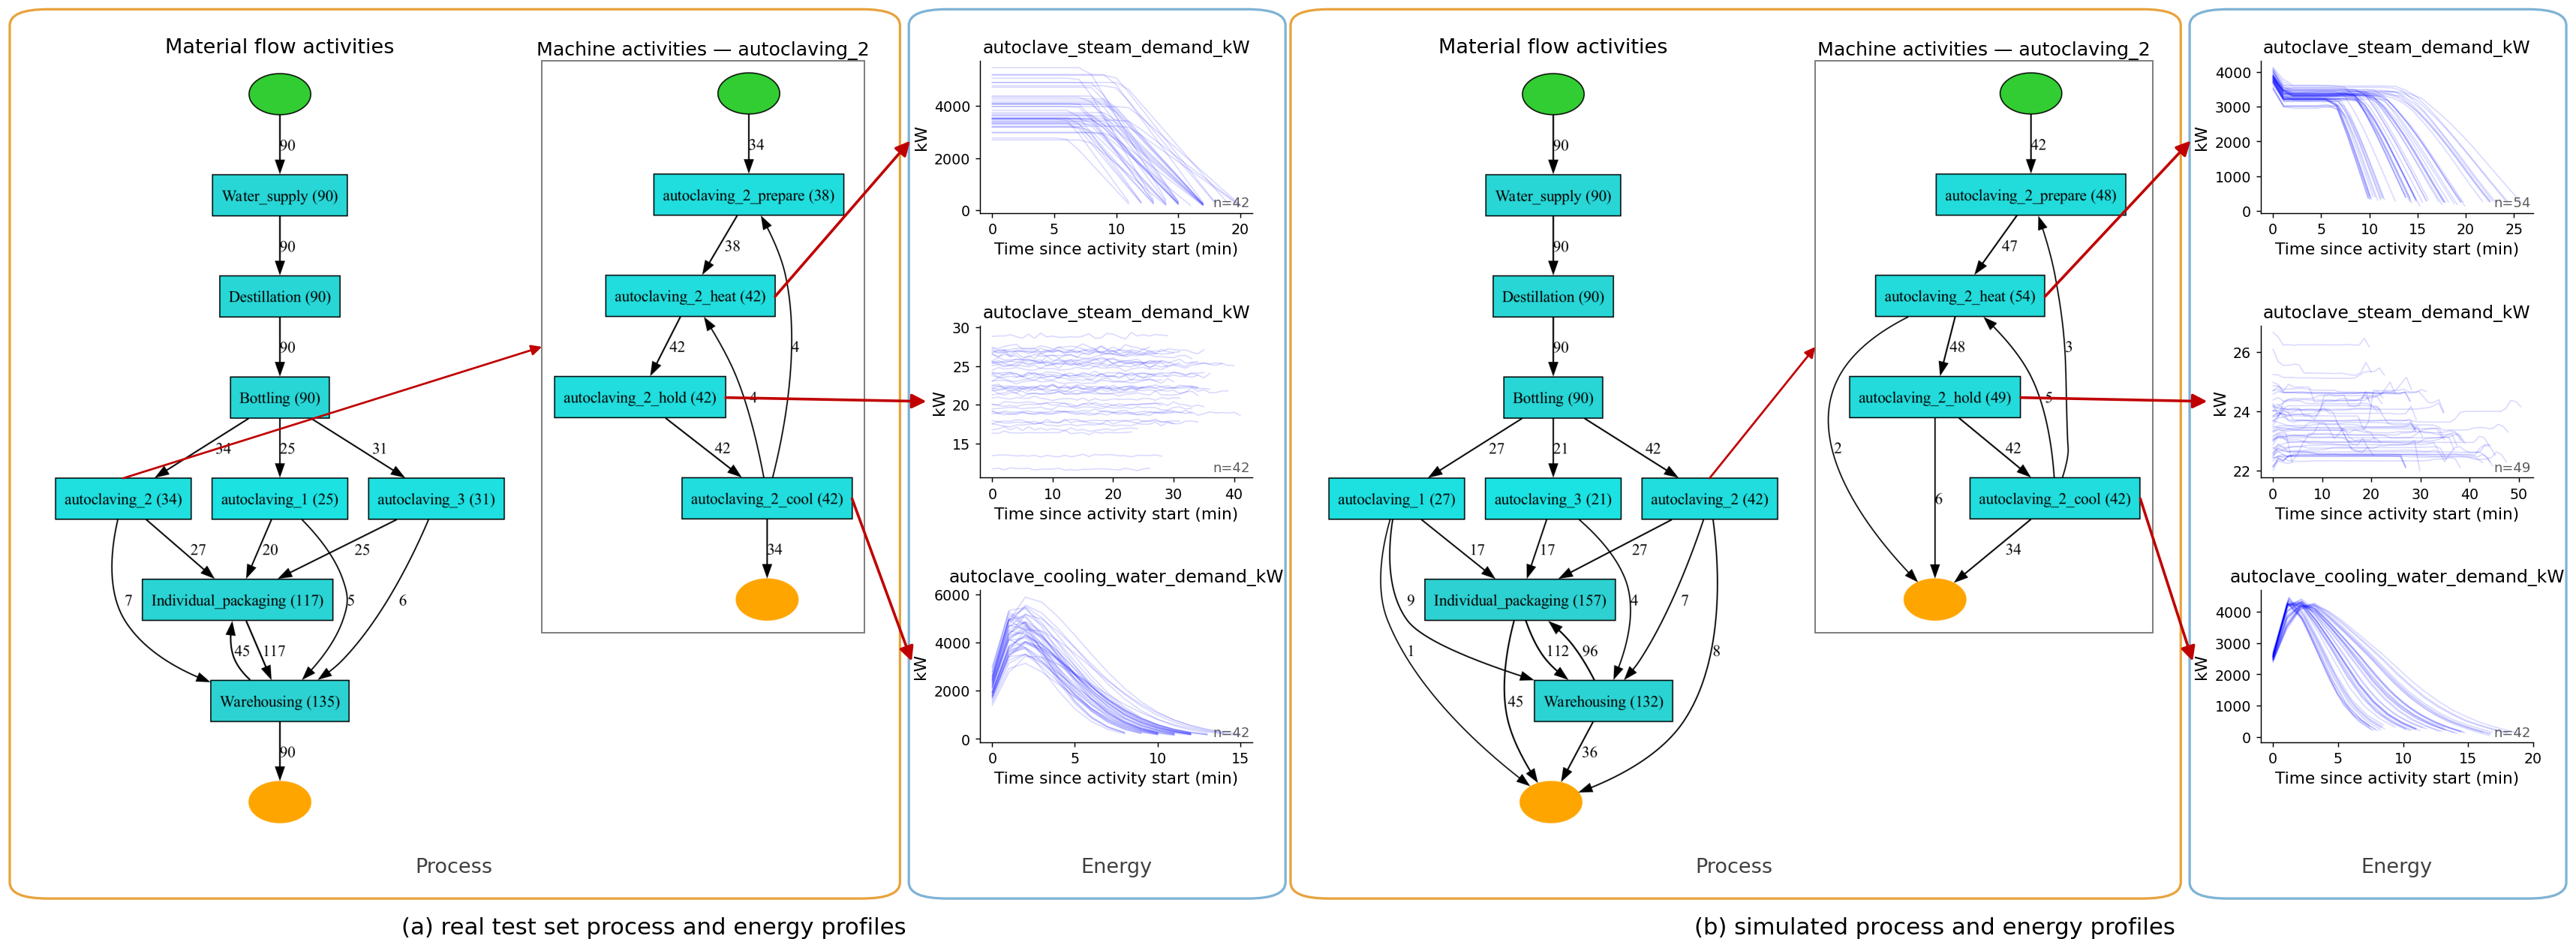

In [21]:
# ── Combined figure: (a) real | (b) simulated ────────────────────────────────
COMBINED_W, COMBINED_H = 26.0, 11.0  # inches; each block gets half the width
COMBINED_FS = 1.00                   # font scale inside a half-width block

# ONE plan for both halves -> same net scale, same panel width, so (a) and (b) are the same size
_plan = plan_blocks([BLOCK_REAL, BLOCK_SIM], COMBINED_W, COMBINED_H, rw=0.5, rh=1.0)

fig = plt.figure(figsize=(COMBINED_W, COMBINED_H))
draw_block(fig, (0.000, 0.0, 0.5, 1.0), BLOCK_REAL, CAPTION_REAL,
           COMBINED_W, COMBINED_H, _plan, fs=COMBINED_FS)
draw_block(fig, (0.505, 0.0, 0.5, 1.0), BLOCK_SIM, CAPTION_SIM,
           COMBINED_W, COMBINED_H, _plan, fs=COMBINED_FS)

if SAVE:
    _p = OUT / f'paper_figure_combined.pdf'
    fig.savefig(_p, format='pdf', bbox_inches='tight', pad_inches=0.15)
    print(f'saved {_p}')
plt.show()
